In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser, NoiseAdder

from config import TEST_SIZE, SEED, MAX_DURATION, MIN_DURATION, SAMPLING_RATE, N_MELS

In [5]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax);

# Conformación del Dataset Final

In [6]:
df = pd.read_csv('./icbhi/ICBHI_ciclos_metadata.csv')

In [7]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


## Duración de los ciclos respiratorios
La aplicación debería contar con un instructivo mostrando el ritmo de respiración esperado. De esta manera los ciclos detectados por el "segmentador" tendrán mas o menos la misma duración, facilitando la segmentación. 

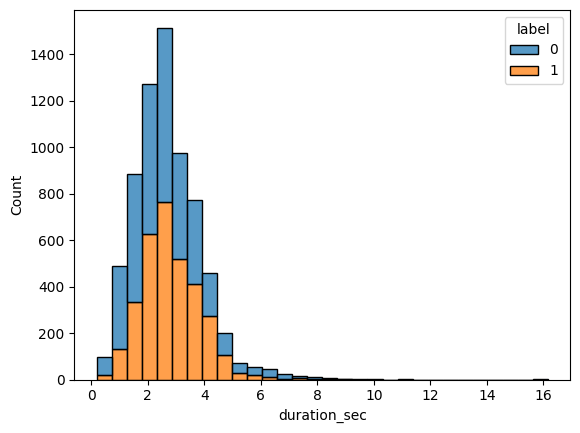

In [8]:
sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

Las duracion sugerida por el instructivo debería estar en el bulk de la distribución observada.  

¿ Qué hacemos con los ciclos que son demasiado cortos? La segmentación no tolera ciclos demasiado cortos.  

Tampoco debería tolerar los demasiado largos, pero esos son pocos y eliminarlos no es tan costoso.

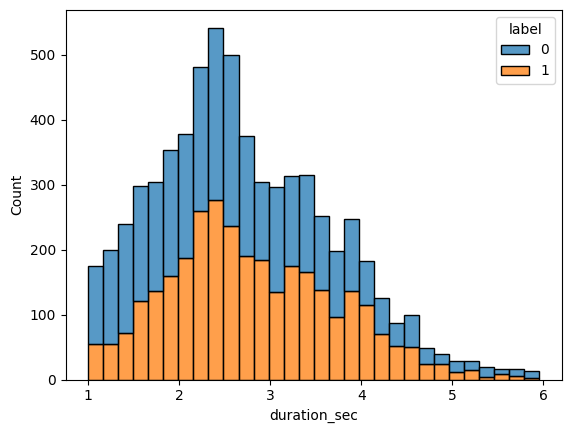

In [9]:
df = df[df['duration_sec'] < MAX_DURATION].copy()
df = df[df['duration_sec'] > MIN_DURATION].copy()

sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

Opción alternativa: multiplicar los audios cortos y recortar los largos.

## Versiones del dataset final
Se plantean dos versiones del dataset final:
1. Versión completa: contiene todos los ciclos respiratorios de la ICBHI RSDB.
    + Ventajas:
        + Mayor cantidad de datos
        + Capa MixStyles en CNN puede usar información adicional (?)
        + En caso de extenderse el uso del modelo a estetoscopios digitales no habría que hacer cambios.
    + Desventajas:
        + Dificultad de adaptar al dominio de smartphones
        + Costo computacional alto (mi máquina no puede correr CV se SK-Learn)
2. Versión filtrada: sólo los audios grabados con el micrófono AKGC417L o desde la tráquea.
    + Ventajas:
        + Menor costo computacional
        + Menor dificultad en adaptar al dominio
        + Más representativo de los audios esperados en producción
    + Desventajas:
        + Pérdida de datos
        + Más específico al caso (puede ser una ventaja también, no aprendería cosas innecesarias)

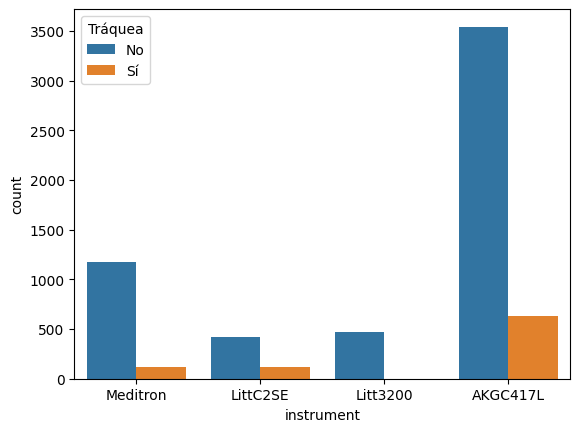

In [10]:
sns.countplot(data=df, x='instrument', hue=df['location'] == 'Tc')
plt.legend(title='Tráquea', labels=['No', 'Sí']);

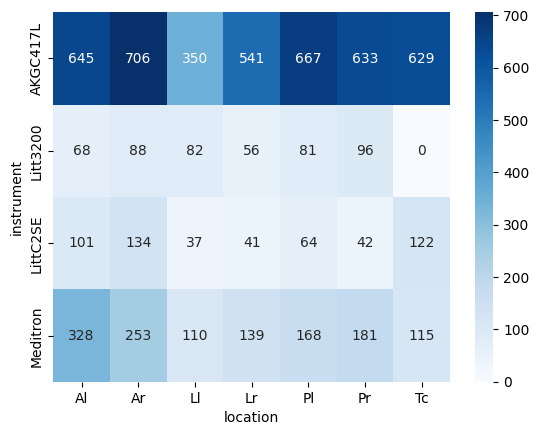

In [11]:
# heatmap instrument vs location
sns.heatmap(pd.crosstab(df['instrument'], df['location']), annot=True, fmt='d', cmap='Blues');

In [12]:
dataset_completo = df.copy()

dataset_filtrado = df[(df['instrument'] == 'AKGC417L') | (df['location'] == 'Tc')].copy()

dataset_filtrado_2 = dataset_filtrado.copy()

dataset_filtrado_2 = dataset_filtrado_2[dataset_filtrado_2['location'].isin(['Tc', 'Al', 'Al'])].copy()

## Balancear

Primero miramos la etiqueta objetivo del futuro modelo

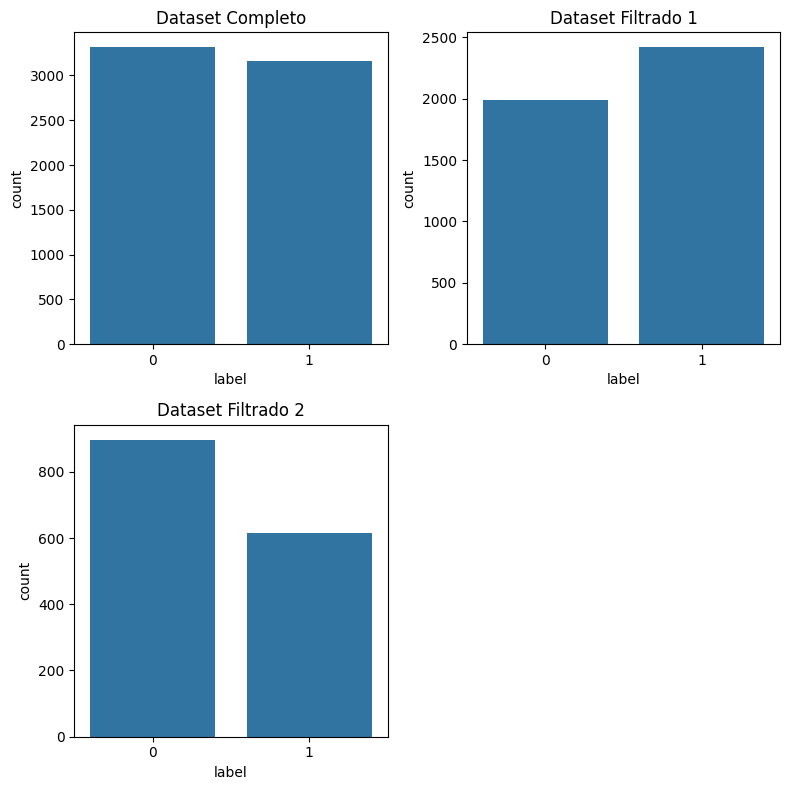

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

fig.delaxes(axes[1, 1])

sns.countplot(data=dataset_completo, x='label', ax=axes[0, 0])
axes[0, 0].set_title('Dataset Completo')
sns.countplot(data=dataset_filtrado, x='label', ax=axes[0, 1])
axes[0, 1].set_title('Dataset Filtrado 1')
sns.countplot(data=dataset_filtrado_2, x='label', ax=axes[1, 0])
axes[1, 0].set_title('Dataset Filtrado 2')
plt.tight_layout();

La variable ``sex`` presenta un desbalance importante. Para evitarlo se pueden usar técnicas durante en el pipeline del modelo final con ``fairlearn`` 

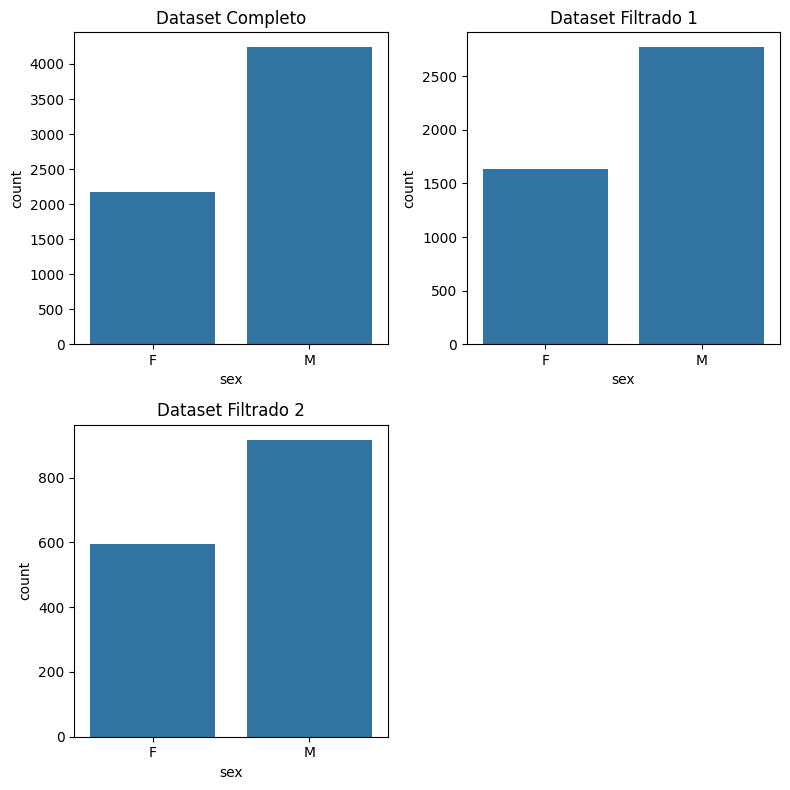

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

fig.delaxes(axes[1, 1])

sns.countplot(data=dataset_completo, x='sex', ax=axes[0, 0])
axes[0, 0].set_title('Dataset Completo')
sns.countplot(data=dataset_filtrado, x='sex', ax=axes[0, 1])
axes[0, 1].set_title('Dataset Filtrado 1')
sns.countplot(data=dataset_filtrado_2, x='sex', ax=axes[1, 0])
axes[1, 0].set_title('Dataset Filtrado 2')
plt.tight_layout();

Vemos las edades, faltan datos entre 20 y 40. No se puede hacer mucho porque no hay datos que duplicar. Simplemente habrá que documentar la limitación.

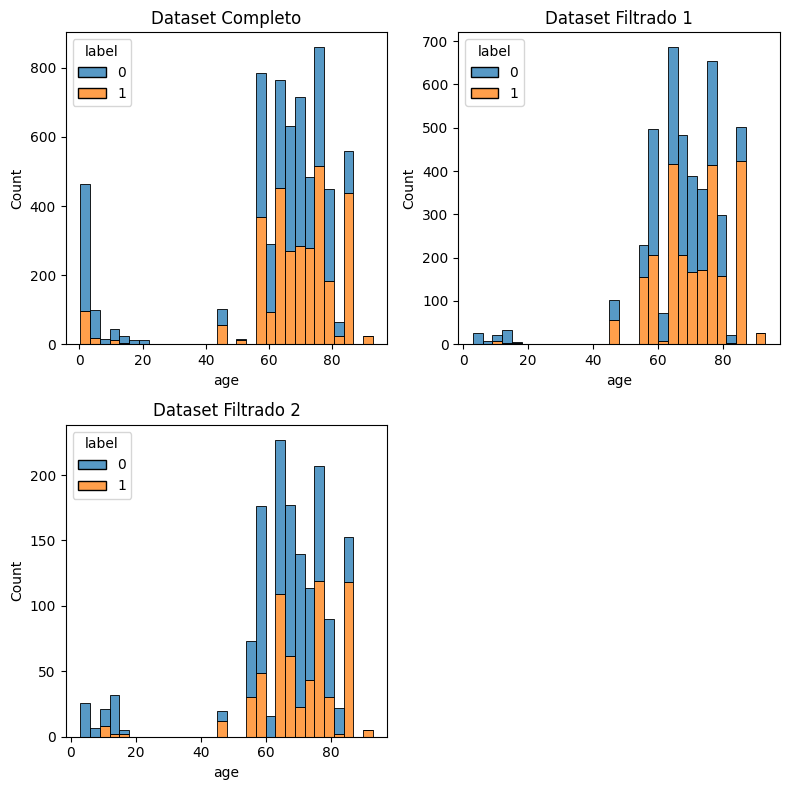

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

fig.delaxes(axes[1, 1])

sns.histplot(data=dataset_completo, x='age', hue='label', multiple="stack", bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Dataset Completo')
sns.histplot(data=dataset_filtrado, x='age', hue='label', multiple="stack", bins=30, ax=axes[0, 1])
axes[0, 1].set_title('Dataset Filtrado 1')
sns.histplot(data=dataset_filtrado_2, x='age', hue='label', multiple="stack", bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Dataset Filtrado 2')
plt.tight_layout();

# Armado de los dos datasets

1. Resampleo a 16 kHz (Segmentador)
2. Agrego ruido (opcional) TODO
3. Filtro pasa bandas

### Completo

In [ ]:
train_completo, test_completo =  train_test_split(dataset_completo[['cycle_wav_file', 'label']], test_size=TEST_SIZE, random_state=SEED, stratify=dataset_completo['label'])

In [14]:
X_train_completo = ['./dataset/ciclos/' + f for f in train_completo['cycle_wav_file']]
X_test_completo = ['./dataset/ciclos/' + f for f in test_completo['cycle_wav_file']]
y_train_completo = train_completo['label'].values
y_test_completo = test_completo['label'].values

**Agrego ruido a los audios de estetoscopios** también podria agregarlos sin reemplazar

In [16]:
indices_stet = [
    i for i, path in enumerate(X_train_completo)
    if "AKGC417" not in path and "Tc" not in path
]
resampler = Resampler()
noise_adder = NoiseAdder()

X_train_resampled = resampler.fit_transform(X_train_completo)

X_train_augmented = X_train_resampled.copy()

for i in indices_stet:
    X_train_augmented[i] = noise_adder.transform([X_train_resampled[i]])[0]

In [21]:
indices_stet = [
    i for i, path in enumerate(X_test_completo)
    if "AKGC417" not in path and "Tc" not in path
]

X_test_resampled = resampler.fit_transform(X_test_completo)

X_test_augmented = X_test_resampled.copy()

for i in indices_stet:
    X_test_augmented[i] = noise_adder.transform([X_test_resampled[i]])[0]

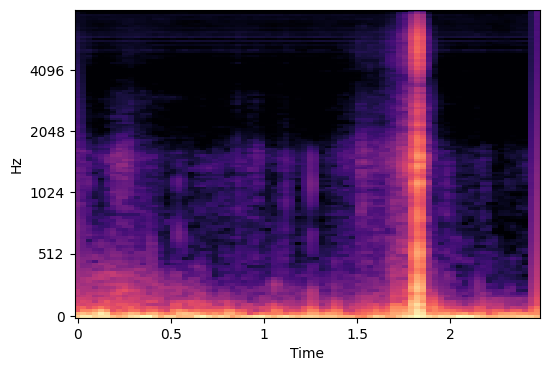

In [27]:
plot_mel_spectrogram(X_train_resampled[indices_stet[2]])

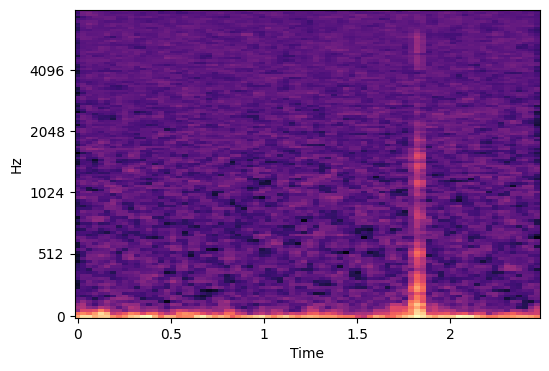

In [28]:
plot_mel_spectrogram(X_train_augmented[indices_stet[2]])

#### Mel espectrograma

In [29]:
pipeline_melspec = Pipeline([
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

Flujo objetivo:  

audio_entero -> **segmentador** -> X -> pipeline.predict(X) | .predict_proba(X) -> output binario

In [30]:
X_train_completo_melspecs = pipeline_melspec.fit_transform(X_train_augmented)
X_test_completo_melspecs = pipeline_melspec.transform(X_test_augmented)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


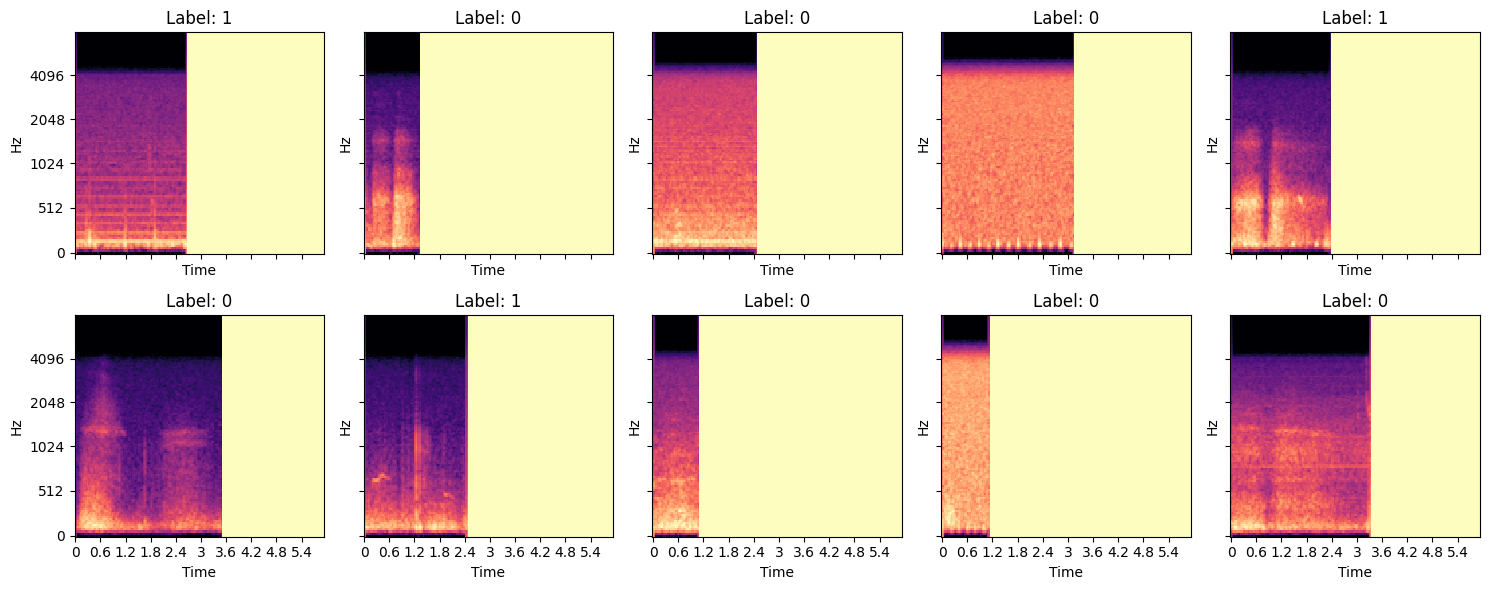

In [31]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_completo_melspecs[i].reshape(128, -1), sr=16000, x_axis='time', y_axis='mel', n_fft=1024, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train_completo[i]}')
plt.tight_layout();

In [32]:
np.savez_compressed(
    './dataset/ciclos_c_r/train_melspectrogram.npz',
    X=X_train_completo_melspecs,
    y=y_train_completo
)

np.savez_compressed(
    './dataset/ciclos_c_r/test_melspectrogram.npz',
    X=X_test_completo_melspecs,
    y=y_test_completo
)

#### Features

In [33]:
pipeline_feature_extraction = Pipeline([
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

In [34]:
X_train_completo_features = pipeline_feature_extraction.fit_transform(X_train_augmented)
X_test_completo_features = pipeline_feature_extraction.transform(X_test_augmented)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [35]:
np.savez_compressed(
    './dataset/ciclos_c_r/train_features.npz',
    X=X_train_completo_features,
    y=y_train_completo
)

np.savez_compressed(
    './dataset/ciclos_c_r/test_features.npz',
    X=X_test_completo_features,
    y=y_test_completo
)

columns='mfcc_' + str(i) for i in range(1, 14), 'zcr', 'energy', 'spectral_centroid', 'spectral_rolloff', 'ber', 'spectral_flatness'

### Filtrado

#### Ruido

Chequear balance y agregar más duplicados con ruido si es necesario.

In [78]:
dataset_filtrado.label.value_counts()

label
1    2420
0    1988
Name: count, dtype: int64

In [79]:
X_paths = ['./dataset/audios_ciclos/' + f for f in dataset_filtrado['cycle_wav_file']]
y = dataset_filtrado['label'].values

In [80]:
resampler = Resampler()
X_resampled = resampler.fit_transform(X_paths)

In [81]:
indices_negativos = np.where(y == 0)[0]

In [82]:
n_pos = np.sum(y == 1)
n_neg = len(indices_negativos)
n_to_augment = n_pos - n_neg

In [83]:
import random

random.seed(SEED)
indices_a_duplicar = random.sample(list(indices_negativos), n_to_augment)

noise_adder = NoiseAdder(snr_min=5, snr_max=10)
X_noisy = noise_adder.transform([X_resampled[i] for i in indices_a_duplicar])

X_augmented = X_resampled + X_noisy # son listas
y_augmented = np.concatenate([y, np.zeros(len(X_noisy), dtype=int)])  # los nuevos también son clase 0

In [84]:
X_train_filtrado, X_test_filtrado, y_train_filtrado, y_test_filtrado = train_test_split(
    X_augmented, y_augmented, test_size=0.2, stratify=y_augmented, random_state=SEED
)

In [85]:
print(f"Train: {len(X_train_filtrado)} | Test: {len(X_test_filtrado)}")
print(f"Distribución Train: {np.bincount(y_train_filtrado)}")
print(f"Distribución Test:  {np.bincount(y_test_filtrado)}")

Train: 3872 | Test: 968
Distribución Train: [1936 1936]
Distribución Test:  [484 484]


#### Mel Espectrogramas

In [86]:
pipeline_melspec = Pipeline([
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

In [87]:
X_train_filtrado_melspecs = pipeline_melspec.fit_transform(X_train_filtrado)
X_test_filtrado_melspecs = pipeline_melspec.transform(X_test_filtrado)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


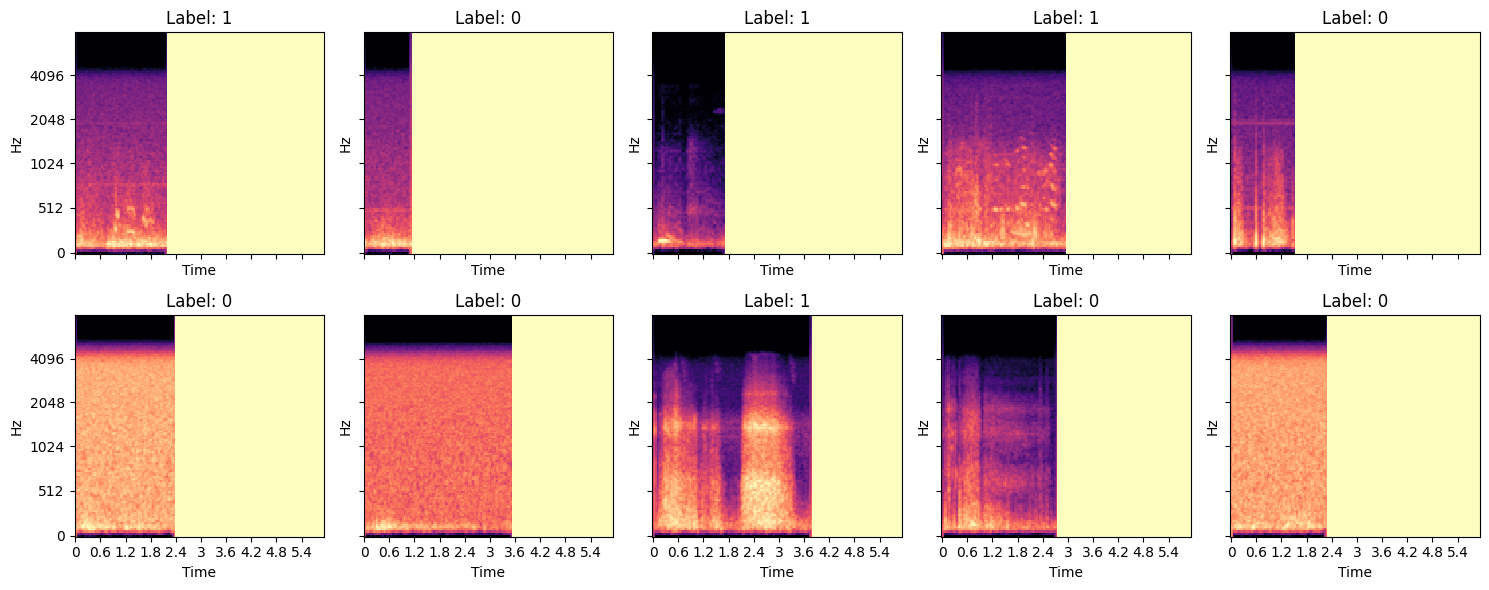

In [88]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_filtrado_melspecs[i].reshape(128, -1), sr=16000, x_axis='time', y_axis='mel', n_fft=1024, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train_filtrado[i]}')
plt.tight_layout();

In [90]:
os.makedirs('./dataset/ciclos_f1_r', exist_ok=True)

np.savez_compressed(
    './dataset/ciclos_f1_r/train_melspectrogram.npz',
    X=X_train_filtrado_melspecs,
    y=y_train_filtrado
)

np.savez_compressed(
    './dataset/ciclos_f1_r/test_melspectrogram.npz',
    X=X_test_filtrado_melspecs,
    y=y_test_filtrado
)

#### Features

In [91]:
pipeline_feature_extraction = Pipeline([
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

In [92]:
X_train_filtrado_features = pipeline_feature_extraction.fit_transform(X_train_filtrado)
X_test_filtrado_features = pipeline_feature_extraction.transform(X_test_filtrado)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [93]:
np.savez_compressed(
    './dataset/ciclos_f1_r/train_features.npz',
    X=X_train_filtrado_features,
    y=y_train_filtrado
)

np.savez_compressed(
    './dataset/ciclos_f1_r/test_features.npz',
    X=X_test_filtrado_features,
    y=y_test_filtrado
)

### Filtrado 2

In [94]:
dataset_filtrado_2.label.value_counts()

label
0    897
1    614
Name: count, dtype: int64

In [95]:
X_paths = ['./dataset/audios_ciclos/' + f for f in dataset_filtrado_2['cycle_wav_file']]
y = dataset_filtrado_2['label'].values

In [96]:
resampler = Resampler()
X_resampled = resampler.fit_transform(X_paths)

In [99]:
indices_postivos = np.where(y == 1)[0]
n_neg = np.sum(y == 0)
n_pos = len(indices_postivos)
n_to_augment = n_neg - n_pos

In [100]:
n_to_augment

np.int64(283)

In [101]:
random.seed(SEED)
indices_a_duplicar = random.sample(list(indices_postivos), n_to_augment)

noise_adder = NoiseAdder(snr_min=5, snr_max=10)
X_noisy = noise_adder.transform([X_resampled[i] for i in indices_a_duplicar])

X_augmented = X_resampled + X_noisy # son listas
y_augmented = np.concatenate([y, np.ones(len(X_noisy), dtype=int)])  # los nuevos también son clase 1

In [102]:
X_train_filtrado_2, X_test_filtrado_2, y_train_filtrado_2, y_test_filtrado_2 = train_test_split(
    X_augmented, y_augmented, test_size=0.2, stratify=y_augmented, random_state=SEED
)

In [103]:
print(f"Train: {len(X_train_filtrado_2)} | Test: {len(X_test_filtrado_2)}")
print(f"Distribución Train: {np.bincount(y_train_filtrado_2)}")
print(f"Distribución Test:  {np.bincount(y_test_filtrado_2)}")

Train: 1435 | Test: 359
Distribución Train: [717 718]
Distribución Test:  [180 179]


#### Mel Espectrogramas

In [104]:
pipeline_melspec = Pipeline([
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

In [105]:
X_train_filtrado_2_melspecs = pipeline_melspec.fit_transform(X_train_filtrado_2)
X_test_filtrado_2_melspecs = pipeline_melspec.transform(X_test_filtrado_2)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


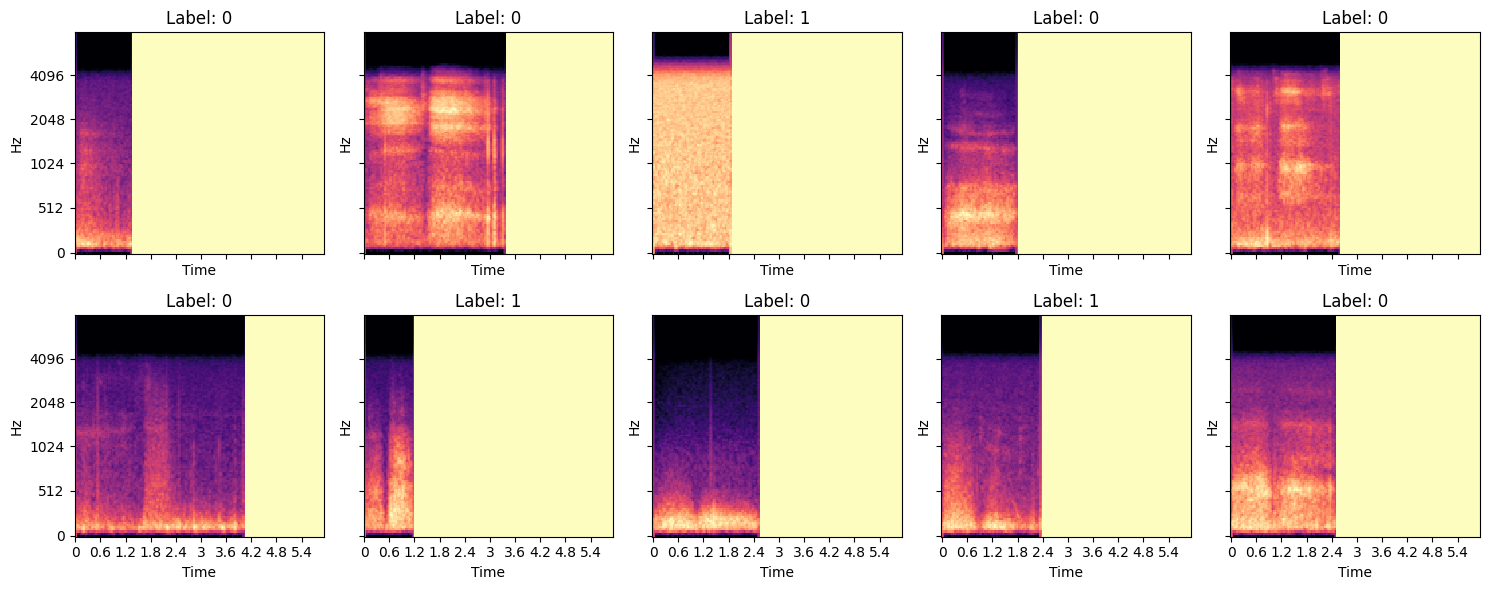

In [106]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_filtrado_2_melspecs[i].reshape(128, -1), sr=16000, x_axis='time', y_axis='mel', n_fft=1024, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train_filtrado_2[i]}')
plt.tight_layout();

In [107]:
os.makedirs('./dataset/ciclos_f2_r', exist_ok=True)

np.savez_compressed(
    './dataset/ciclos_f2_r/train_melspectrogram.npz',
    X=X_train_filtrado_2_melspecs,
    y=y_train_filtrado_2
)

np.savez_compressed(
    './dataset/ciclos_f2_r/test_melspectrogram.npz',
    X=X_test_filtrado_2_melspecs,
    y=y_test_filtrado_2
)

#### Features

In [108]:
pipeline_feature_extraction = Pipeline([
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

In [109]:
X_train_filtrado_2_features = pipeline_feature_extraction.fit_transform(X_train_filtrado_2)
X_test_filtrado_2_features = pipeline_feature_extraction.transform(X_test_filtrado_2)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [110]:
np.savez_compressed(
    './dataset/ciclos_f2_r/train_features.npz',
    X=X_train_filtrado_2_features,
    y=y_train_filtrado_2
)

np.savez_compressed(
    './dataset/ciclos_f2_r/test_features.npz',
    X=X_test_filtrado_2_features,
    y=y_test_filtrado_2
)